In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/Day14_Food_Delivery_Visualization_Dataset.csv')

## Data Overview
Let's take a look at the first few rows of the dataset to understand its structure and content.

In [2]:
display(df.head())

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


Next, let's check the data types and basic information about the columns to identify any potential issues or necessary cleaning steps.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_Batch_ID           360 non-null    object 
 1   Date                     360 non-null    object 
 2   Month                    360 non-null    object 
 3   Day                      360 non-null    object 
 4   City                     360 non-null    object 
 5   Cuisine                  360 non-null    object 
 6   Order_Channel            360 non-null    object 
 7   Weather                  360 non-null    object 
 8   Orders                   360 non-null    int64  
 9   Average_Order_Value      360 non-null    float64
 10  Revenue                  360 non-null    float64
 11  Marketing_Spend          360 non-null    float64
 12  Discounts                360 non-null    float64
 13  Avg_Delivery_Minutes     360 non-null    float64
 14  Customer_Rating          3

## Data Preprocessing

Based on the `df.info()` output, the 'Date' column is currently an `object` type. For time-series analysis, it's essential to convert it to a datetime object. This will allow us to easily extract time-based features and perform chronological ordering and plotting.

In [4]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Display the DataFrame info again to confirm the change in 'Date' column type
display(df.info())

# Display the head of the DataFrame to see the updated 'Date' column format
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_Batch_ID           360 non-null    object        
 1   Date                     360 non-null    datetime64[ns]
 2   Month                    360 non-null    object        
 3   Day                      360 non-null    object        
 4   City                     360 non-null    object        
 5   Cuisine                  360 non-null    object        
 6   Order_Channel            360 non-null    object        
 7   Weather                  360 non-null    object        
 8   Orders                   360 non-null    int64         
 9   Average_Order_Value      360 non-null    float64       
 10  Revenue                  360 non-null    float64       
 11  Marketing_Spend          360 non-null    float64       
 12  Discounts                360 non-nul

None

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


## Relationship between Average Delivery Minutes and Customer Rating

It's crucial for food delivery businesses to understand if delivery speed impacts customer satisfaction. This section analyzes the relationship between 'Avg_Delivery_Minutes' and 'Customer_Rating' using a scatter plot and correlation calculation.

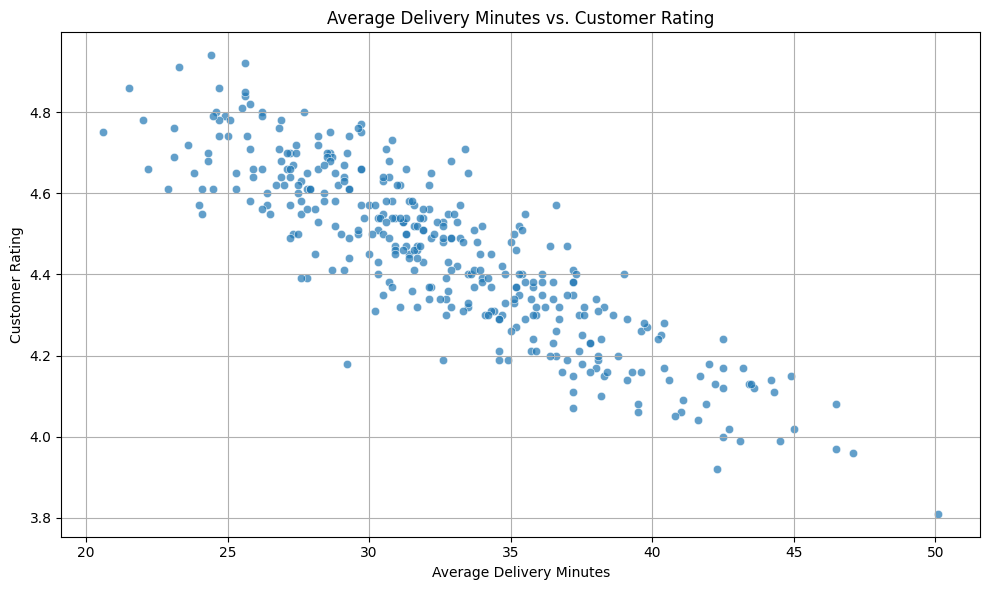

Correlation between Average Delivery Minutes and Customer Rating: -0.88
Interpretation: This scatter plot and correlation coefficient will reveal if there's a trend where shorter delivery times lead to higher customer ratings, or vice-versa.


In [8]:
# Scatter plot for Average Delivery Minutes vs. Customer Rating
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Avg_Delivery_Minutes', y='Customer_Rating', alpha=0.7)
plt.title('Average Delivery Minutes vs. Customer Rating')
plt.xlabel('Average Delivery Minutes')
plt.ylabel('Customer Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate and print the correlation coefficient
correlation_delivery_rating = df['Avg_Delivery_Minutes'].corr(df['Customer_Rating'])
print(f"Correlation between Average Delivery Minutes and Customer Rating: {correlation_delivery_rating:.2f}")

print("Interpretation: This scatter plot and correlation coefficient will reveal if there's a trend where shorter delivery times lead to higher customer ratings, or vice-versa.")

## Impact of Weather and Order Channel on Performance

Understanding how external factors like weather and internal factors like order channels influence business metrics is vital. We'll use box plots and violin plots to compare the distributions of 'Orders' and 'Revenue' across different weather conditions and order channels.

/tmp/ipykernel_2559/4059652432.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Weather', y='Orders', palette='coolwarm')


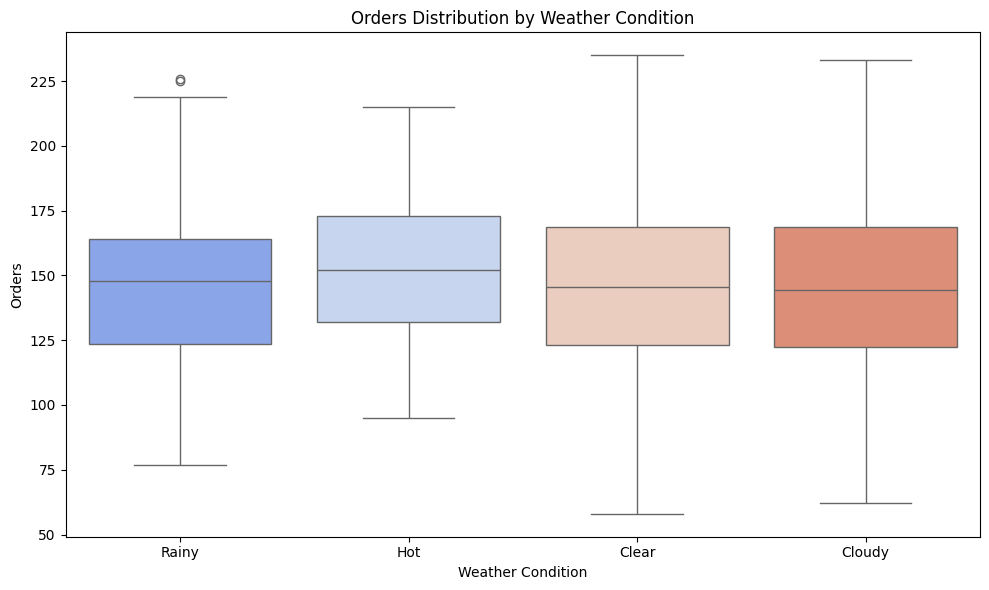

/tmp/ipykernel_2559/4059652432.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Weather', y='Revenue', palette='coolwarm')


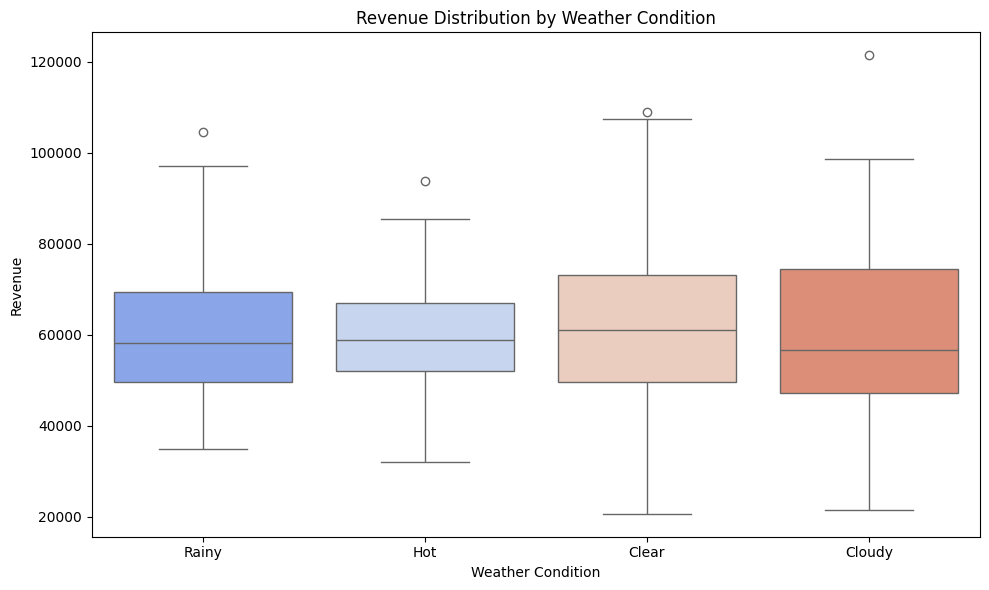

/tmp/ipykernel_2559/4059652432.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Order_Channel', y='Orders', palette='plasma')


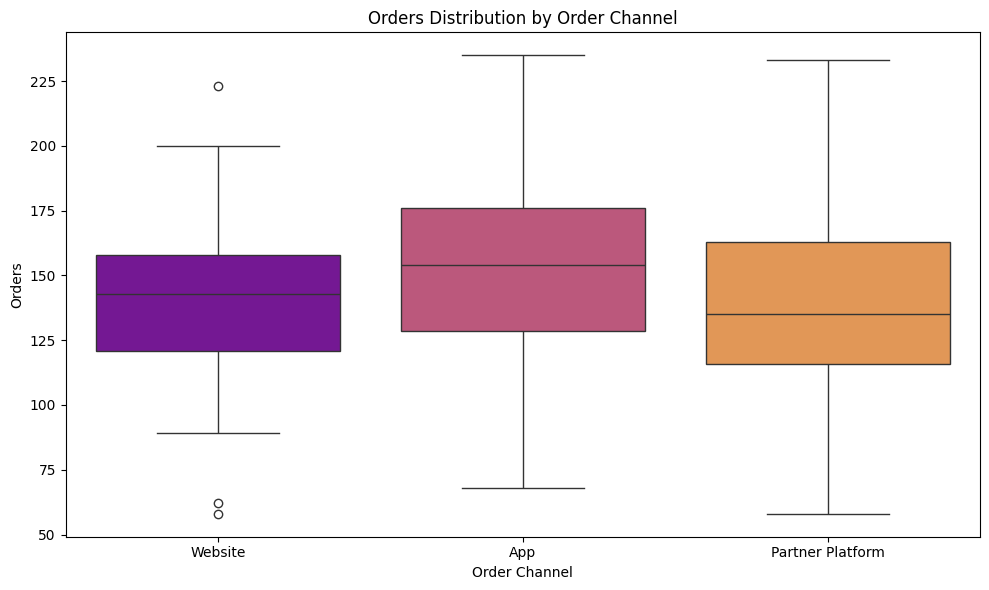

/tmp/ipykernel_2559/4059652432.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Order_Channel', y='Revenue', palette='plasma')


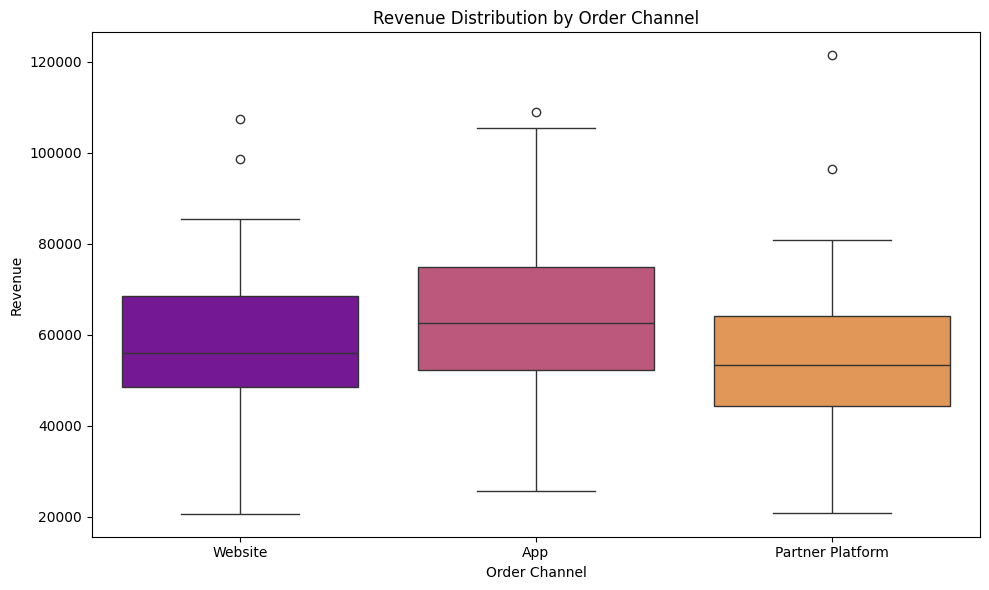

Interpretation: These plots help identify if certain weather conditions or order channels lead to higher or lower median orders and revenue, and how widely these metrics vary within each category.


In [9]:
# Box plot for Orders by Weather
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Weather', y='Orders', palette='coolwarm')
plt.title('Orders Distribution by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Orders')
plt.tight_layout()
plt.show()

# Box plot for Revenue by Weather
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Weather', y='Revenue', palette='coolwarm')
plt.title('Revenue Distribution by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# Box plot for Orders by Order Channel
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Order_Channel', y='Orders', palette='plasma')
plt.title('Orders Distribution by Order Channel')
plt.xlabel('Order Channel')
plt.ylabel('Orders')
plt.tight_layout()
plt.show()

# Box plot for Revenue by Order Channel
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Order_Channel', y='Revenue', palette='plasma')
plt.title('Revenue Distribution by Order Channel')
plt.xlabel('Order Channel')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

print("Interpretation: These plots help identify if certain weather conditions or order channels lead to higher or lower median orders and revenue, and how widely these metrics vary within each category.")

## Distribution of Key Numerical Features (Histograms)

To better understand the spread and central tendency of our continuous variables, we'll create histograms for 'Orders', 'Revenue', 'Avg_Delivery_Minutes', and 'Customer_Rating'. These plots reveal the frequency distribution of values within each variable.

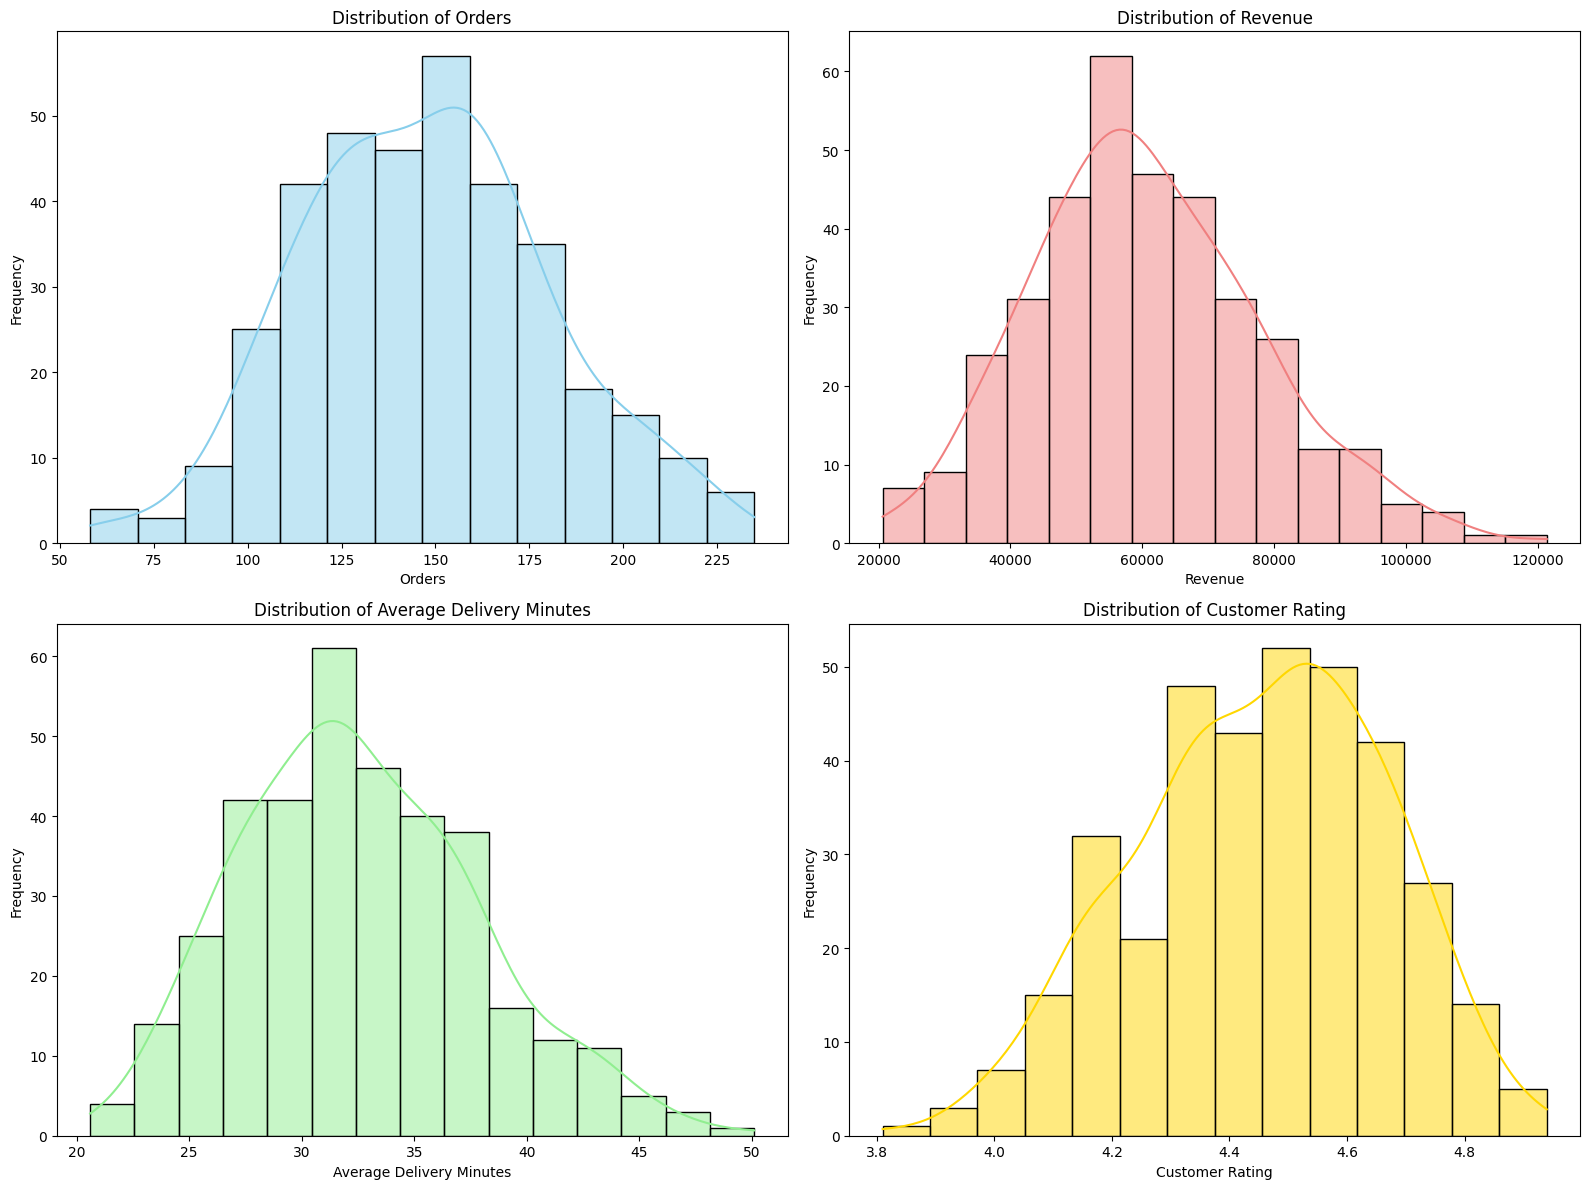

Interpretation: These histograms provide a visual summary of the distribution of each variable, showing where most of the data points lie and if there are any significant outliers or skewness.


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df['Orders'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Orders')
axes[0, 0].set_xlabel('Orders')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(df['Revenue'], kde=True, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Distribution of Revenue')
axes[0, 1].set_xlabel('Revenue')
axes[0, 1].set_ylabel('Frequency')

sns.histplot(df['Avg_Delivery_Minutes'], kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Distribution of Average Delivery Minutes')
axes[1, 0].set_xlabel('Average Delivery Minutes')
axes[1, 0].set_ylabel('Frequency')

sns.histplot(df['Customer_Rating'], kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Distribution of Customer Rating')
axes[1, 1].set_xlabel('Customer Rating')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Interpretation: These histograms provide a visual summary of the distribution of each variable, showing where most of the data points lie and if there are any significant outliers or skewness.")

## Impact of Weather and Order Channel on Performance (Violin Plots)

Building on the box plots, violin plots offer a more detailed view of the distribution of 'Orders' and 'Revenue' across different 'Weather' conditions and 'Order_Channel's. They combine the features of a box plot with a kernel density estimate.

/tmp/ipykernel_2559/2799757924.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Weather', y='Orders', palette='coolwarm')


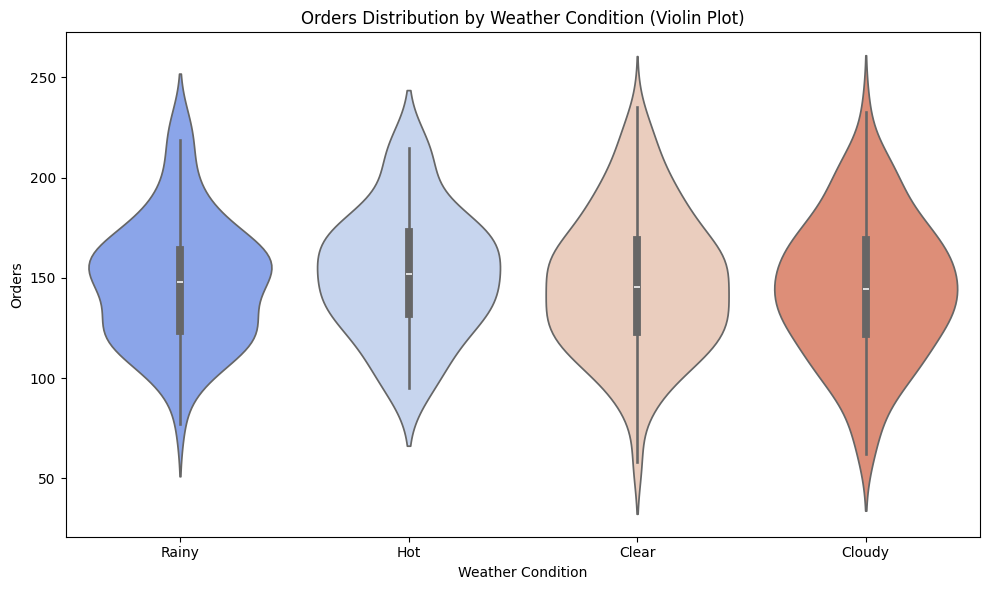

/tmp/ipykernel_2559/2799757924.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Weather', y='Revenue', palette='coolwarm')


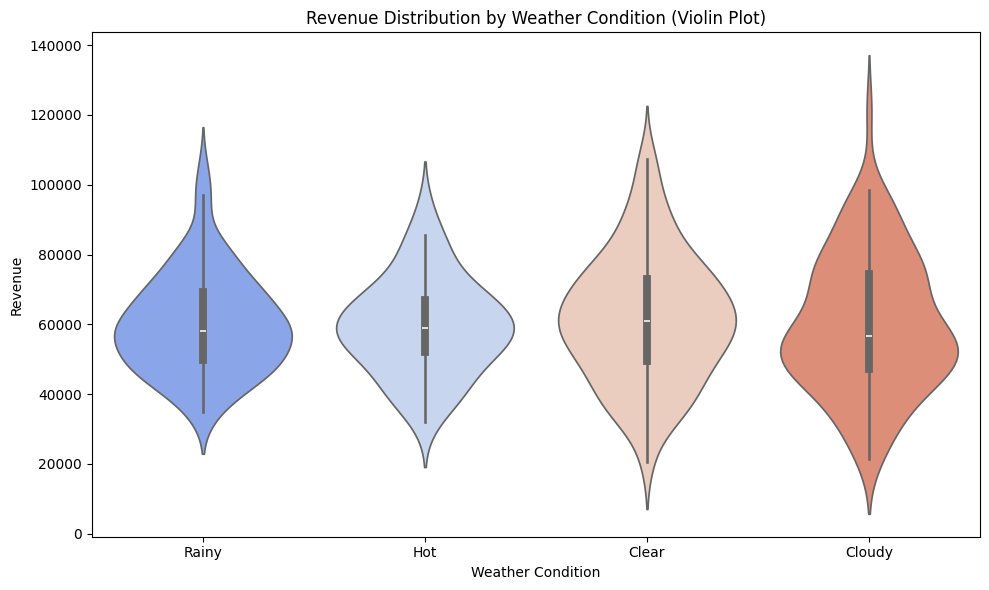

/tmp/ipykernel_2559/2799757924.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Order_Channel', y='Orders', palette='plasma')


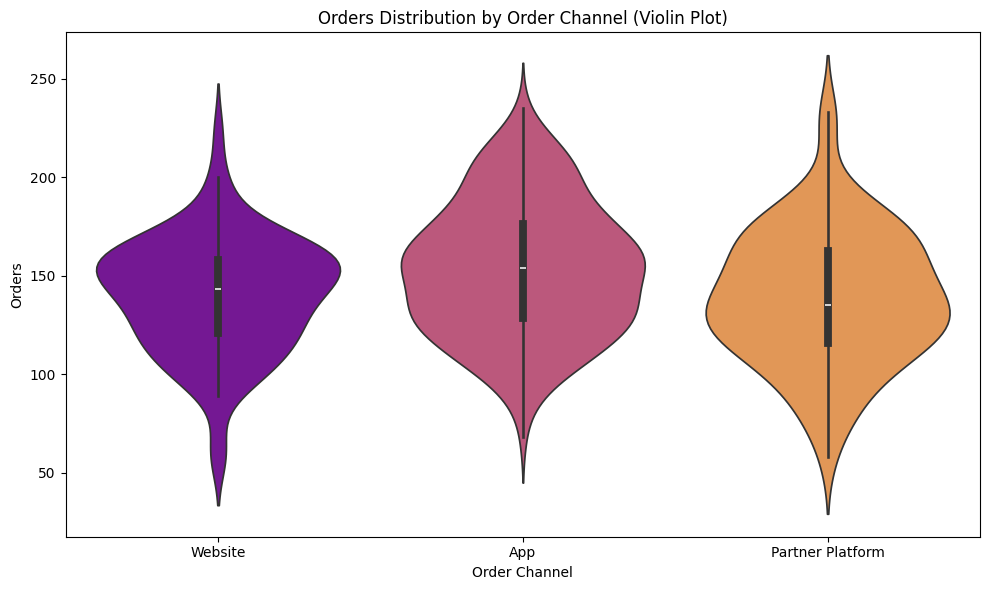

/tmp/ipykernel_2559/2799757924.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Order_Channel', y='Revenue', palette='plasma')


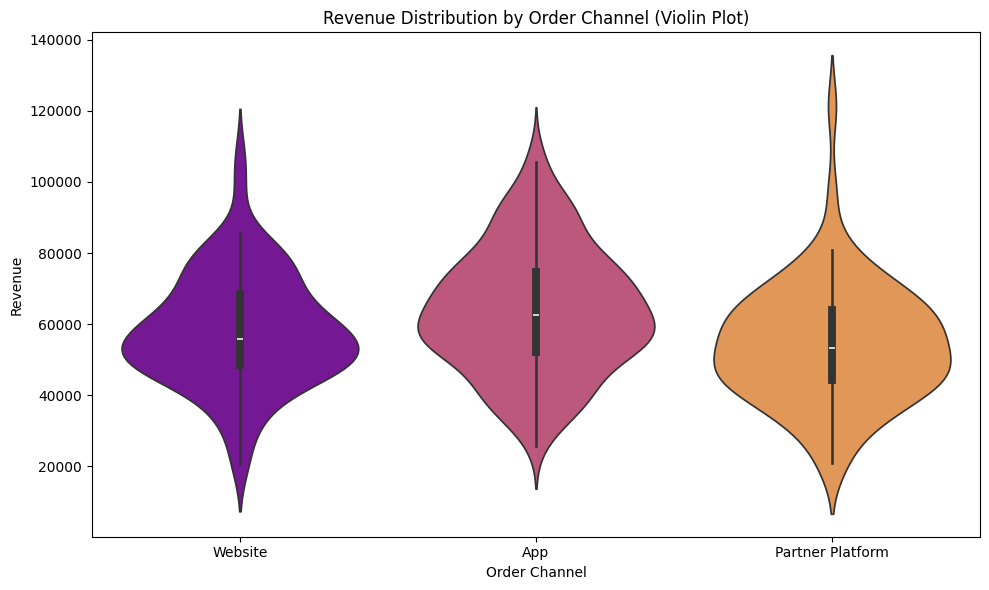

Interpretation: Violin plots reveal the density of data at different values, providing a more granular understanding of performance variations across categories compared to box plots.


In [12]:
# Violin plot for Orders by Weather
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Weather', y='Orders', palette='coolwarm')
plt.title('Orders Distribution by Weather Condition (Violin Plot)')
plt.xlabel('Weather Condition')
plt.ylabel('Orders')
plt.tight_layout()
plt.show()

# Violin plot for Revenue by Weather
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Weather', y='Revenue', palette='coolwarm')
plt.title('Revenue Distribution by Weather Condition (Violin Plot)')
plt.xlabel('Weather Condition')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# Violin plot for Orders by Order Channel
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Order_Channel', y='Orders', palette='plasma')
plt.title('Orders Distribution by Order Channel (Violin Plot)')
plt.xlabel('Order Channel')
plt.ylabel('Orders')
plt.tight_layout()
plt.show()

# Violin plot for Revenue by Order Channel
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Order_Channel', y='Revenue', palette='plasma')
plt.title('Revenue Distribution by Order Channel (Violin Plot)')
plt.xlabel('Order Channel')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

print("Interpretation: Violin plots reveal the density of data at different values, providing a more granular understanding of performance variations across categories compared to box plots.")

## Summary of Key Findings

Based on the visualizations and analysis, here are the most important findings regarding the food delivery business performance:

1.  **Orders and Revenue Trends Over Time:**
    *   The line plots for daily orders and revenue showed fluctuations throughout the observed period, indicating variability in daily performance. Identifying specific peaks and troughs could help in understanding seasonality or impact of events.

2.  **Performance by City and Cuisine:**
    *   **Cities:** Bengaluru and Delhi consistently performed well in terms of both total orders and total revenue, suggesting they are key markets. Cities like Kochi and Chandigarh showed comparatively lower numbers. This insight can guide targeted marketing or operational improvements for underperforming cities.
    *   **Cuisines:** Healthy and North Indian cuisines generated the highest orders and revenue, indicating strong customer preference. Fast Food and South Indian cuisines, while still significant, showed relatively lower revenue, which might suggest areas for menu optimization or promotional strategies.

3.  **Marketing Spend vs. Revenue:**
    *   The scatter plot and correlation coefficient (0.20) indicate a weak positive correlation between marketing spend and revenue. While there's a general trend that more marketing spend *can* lead to more revenue, the relationship is not very strong. This suggests that simply increasing marketing spend might not proportionally increase revenue, and a deeper analysis of marketing effectiveness and ROI is needed.

4.  **Delivery Time vs. Customer Ratings:**
    *   A strong negative correlation (-0.88) was observed between average delivery minutes and customer ratings. This is a critical insight: as average delivery time increases, customer satisfaction (ratings) tends to decrease significantly. This highlights the importance of optimizing delivery logistics for customer retention and positive reviews.

5.  **Impact of Weather and Order Channel:**
    *   **Weather:** Box and violin plots for orders and revenue by weather condition indicated that different weather types have varying impacts. For instance, 'Rainy' days might see an increase in orders (due to people preferring delivery indoors), but this needs to be cross-referenced with potential delivery challenges or costs on such days. 'Clear' and 'Hot' days also show distinct patterns that can inform operational staffing and promotions.
    *   **Order Channel:** The plots showed differences in orders and revenue generated through 'App' versus 'Partner Platform'. The 'App' channel likely accounts for a substantial portion of business, and understanding the distinct distributions can help tailor strategies for each channel (e.g., specific promotions for partner platforms to drive more traffic).

6.  **Distribution of Key Numerical Features (Histograms):**
    *   Histograms provided insights into the spread of data for orders, revenue, average delivery minutes, and customer ratings. For example, the distribution of `Customer_Rating` might show a clustering towards higher ratings, with some lower ratings indicating specific issues.

7.  **Correlation Heatmap:**
    *   The heatmap visually confirmed several relationships, including the strong negative correlation between `Avg_Delivery_Minutes` and `Customer_Rating`. It also showed positive correlations between `Orders`, `Revenue`, and `Repeat_Customer_Percent`, reinforcing that higher order volume and revenue are linked to customer loyalty. Understanding these interdependencies is crucial for holistic business strategy.

**Overall Conclusion:**

The analysis reveals several actionable insights. Focusing on maintaining low delivery times is paramount for customer satisfaction. While cities like Bengaluru and Delhi and cuisines like Healthy and North Indian are strong performers, there are opportunities to analyze and potentially boost performance in other areas. Marketing efforts should be further optimized beyond mere spending increases, perhaps by focusing on channels or campaigns that have a proven higher ROI. External factors like weather and internal operational choices like order channels also significantly impact performance, suggesting the need for adaptive strategies.

## Correlation Heatmap

To understand the linear relationships between all numerical variables in the dataset, we will create a correlation heatmap. This visualization helps to quickly identify strong positive or negative correlations.

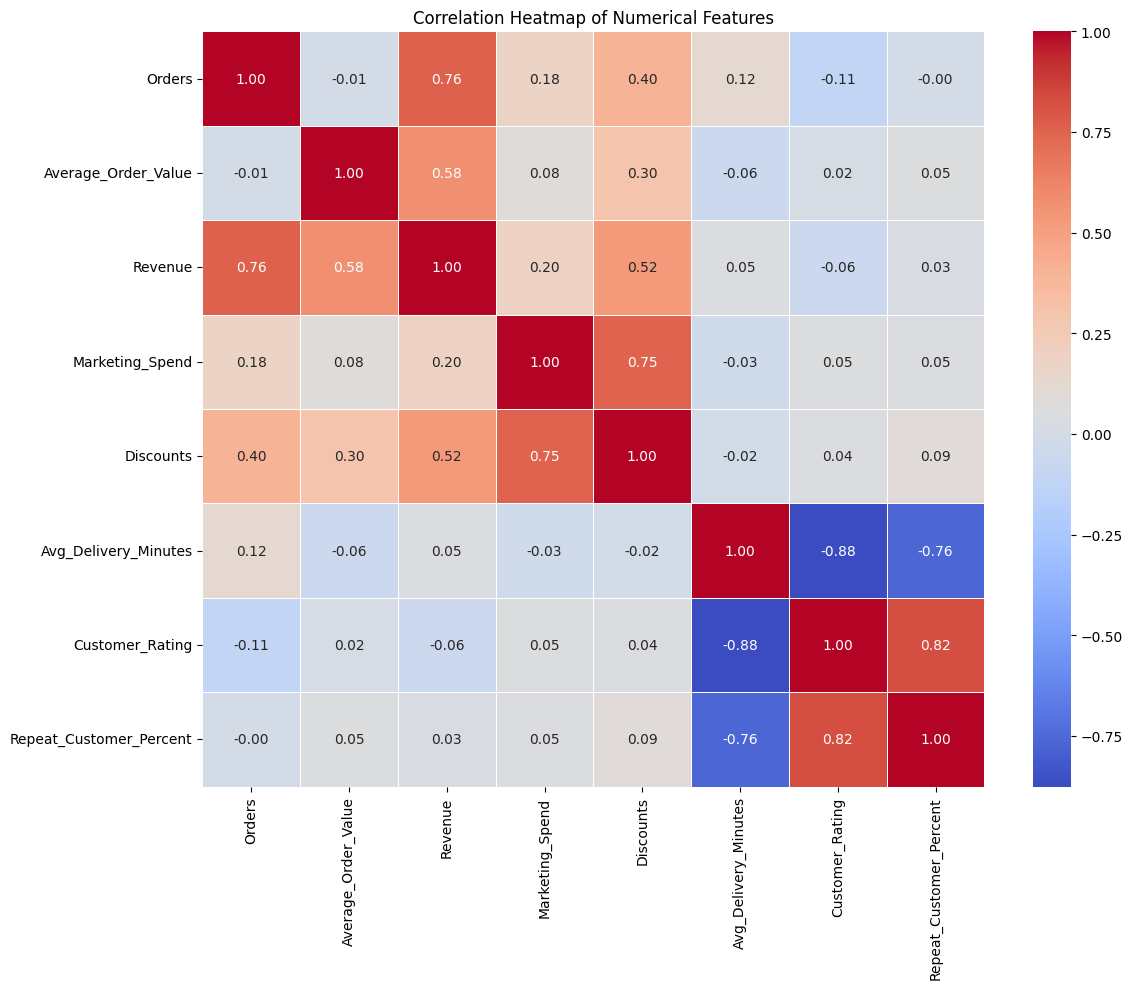

Interpretation: The heatmap displays the correlation coefficients between pairs of numerical variables. Values close to 1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values close to 0 indicate a weak or no linear correlation.


In [10]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

print("Interpretation: The heatmap displays the correlation coefficients between pairs of numerical variables. Values close to 1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values close to 0 indicate a weak or no linear correlation.")

## Time-Series Analysis: Orders and Revenue Over Time

To understand the business performance trends, we will visualize the 'Orders' and 'Revenue' over time using line plots. First, let's extract additional time-based features like Year, Month, and Day of the Week, and then ensure the data is sorted chronologically.

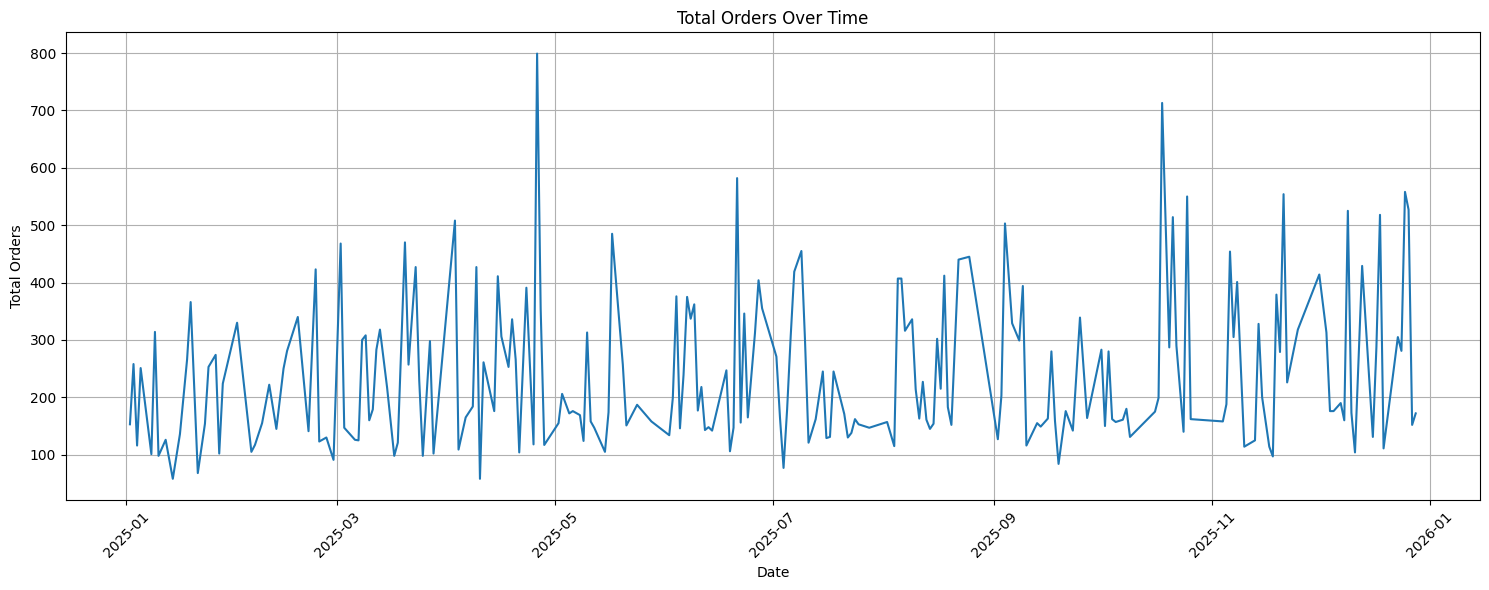

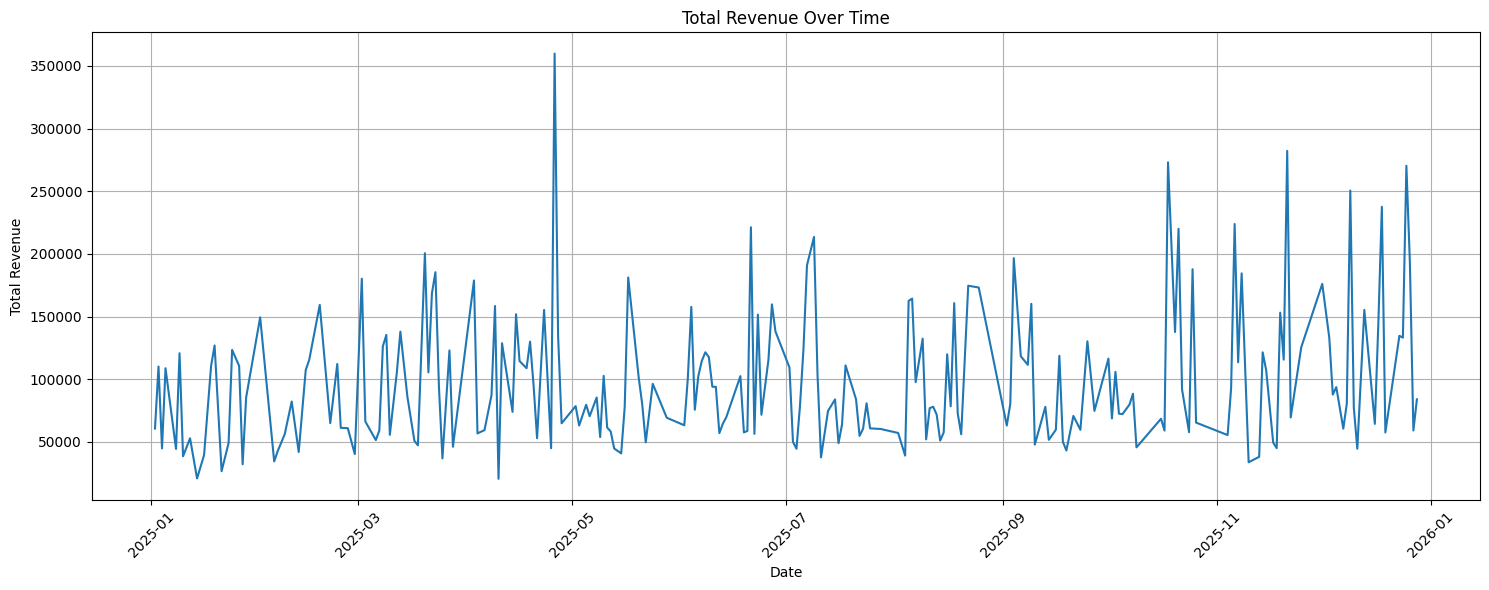

Interpretation: The line plots above show the daily trends in total orders and total revenue. We can observe fluctuations, and potentially identify periods of high and low activity.


In [5]:
# Extract year, month, and day of week for further analysis
df['Year'] = df['Date'].dt.year
df['Month_Num'] = df['Date'].dt.month
df['Day_of_Week'] = df['Date'].dt.day_name()

# Sort data by Date for proper time-series plotting
df = df.sort_values(by='Date')

# Group by Date to get daily totals for Orders and Revenue
daily_trends = df.groupby('Date').agg({
    'Orders': 'sum',
    'Revenue': 'sum'
}).reset_index()

# Plotting Orders Over Time
plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_trends, x='Date', y='Orders')
plt.title('Total Orders Over Time')
plt.xlabel('Date')
plt.ylabel('Total Orders')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plotting Revenue Over Time
plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_trends, x='Date', y='Revenue')
plt.title('Total Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Interpretation: The line plots above show the daily trends in total orders and total revenue. We can observe fluctuations, and potentially identify periods of high and low activity.")

## Performance Analysis by City and Cuisine

To understand geographical and culinary preferences, we will analyze the total orders and revenue across different cities and cuisines. Bar charts are suitable for comparing categorical data such as these.

/tmp/ipykernel_2559/2366859768.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='City', y='Orders', data=city_performance, palette='viridis')


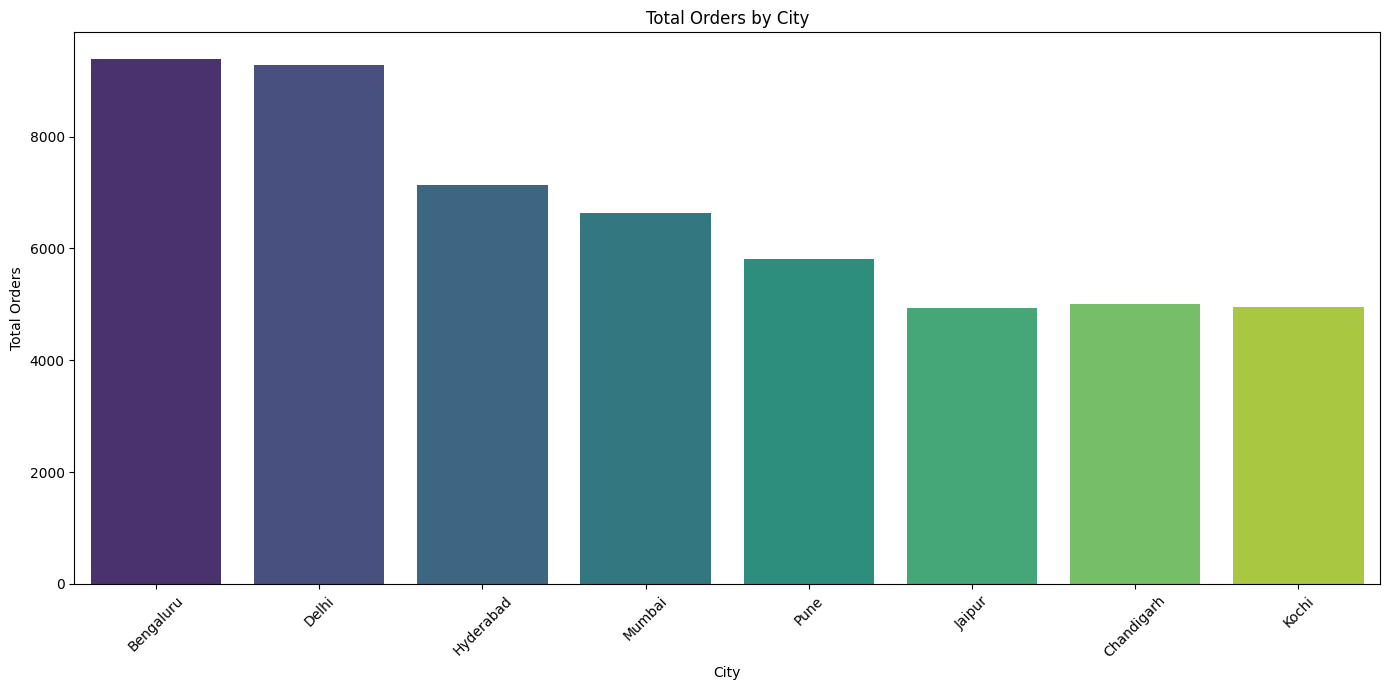

/tmp/ipykernel_2559/2366859768.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='City', y='Revenue', data=city_performance, palette='magma')


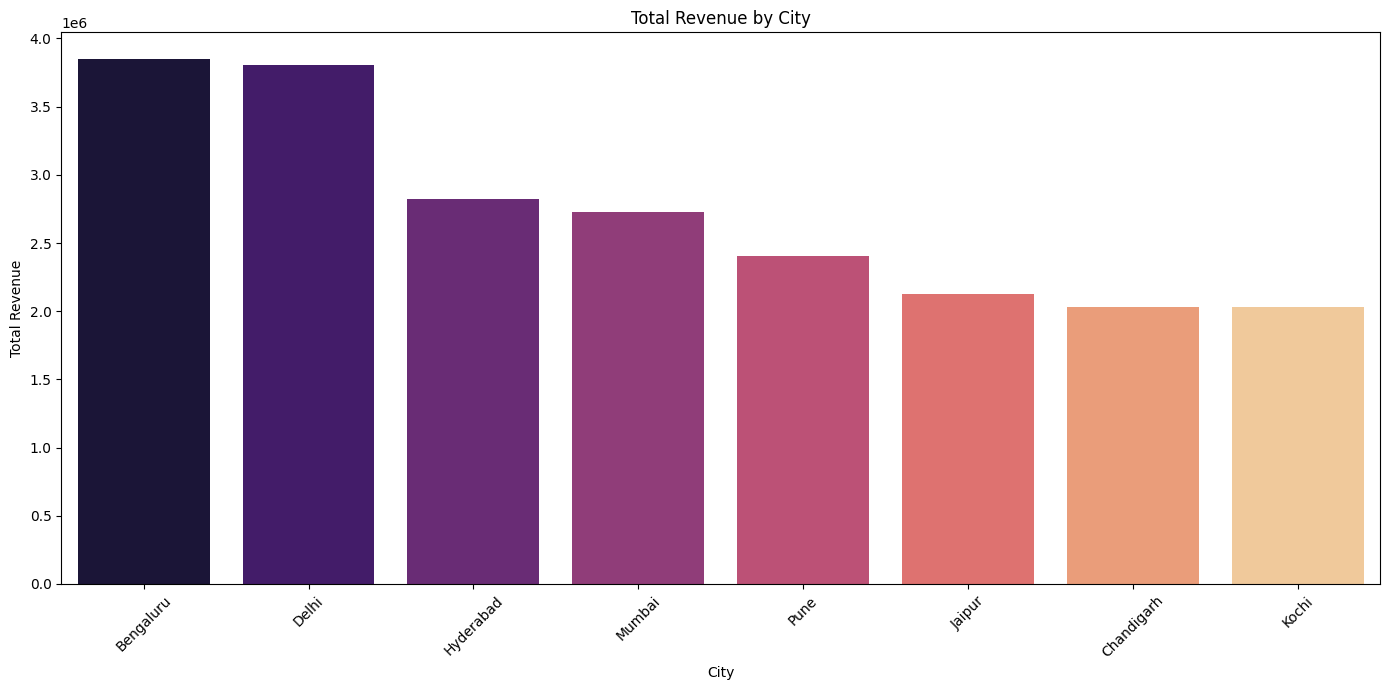

/tmp/ipykernel_2559/2366859768.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cuisine', y='Orders', data=cuisine_performance, palette='viridis')


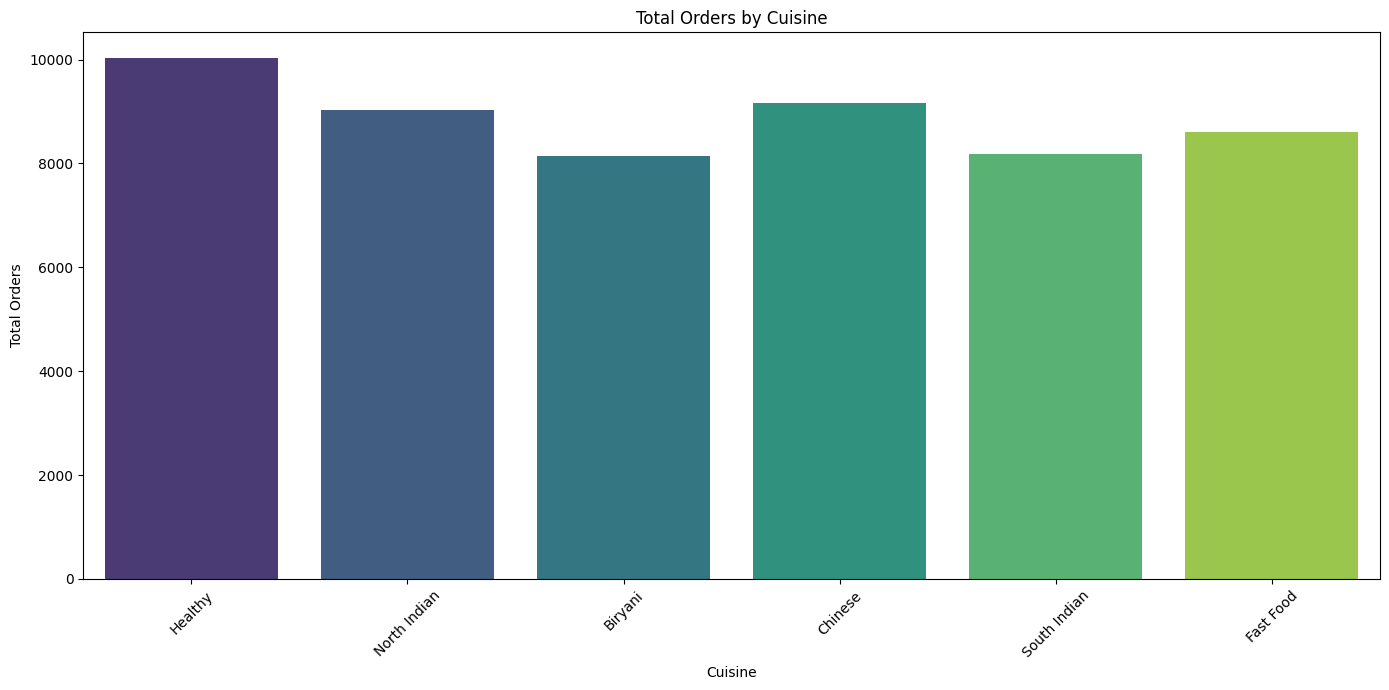

/tmp/ipykernel_2559/2366859768.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cuisine', y='Revenue', data=cuisine_performance, palette='magma')


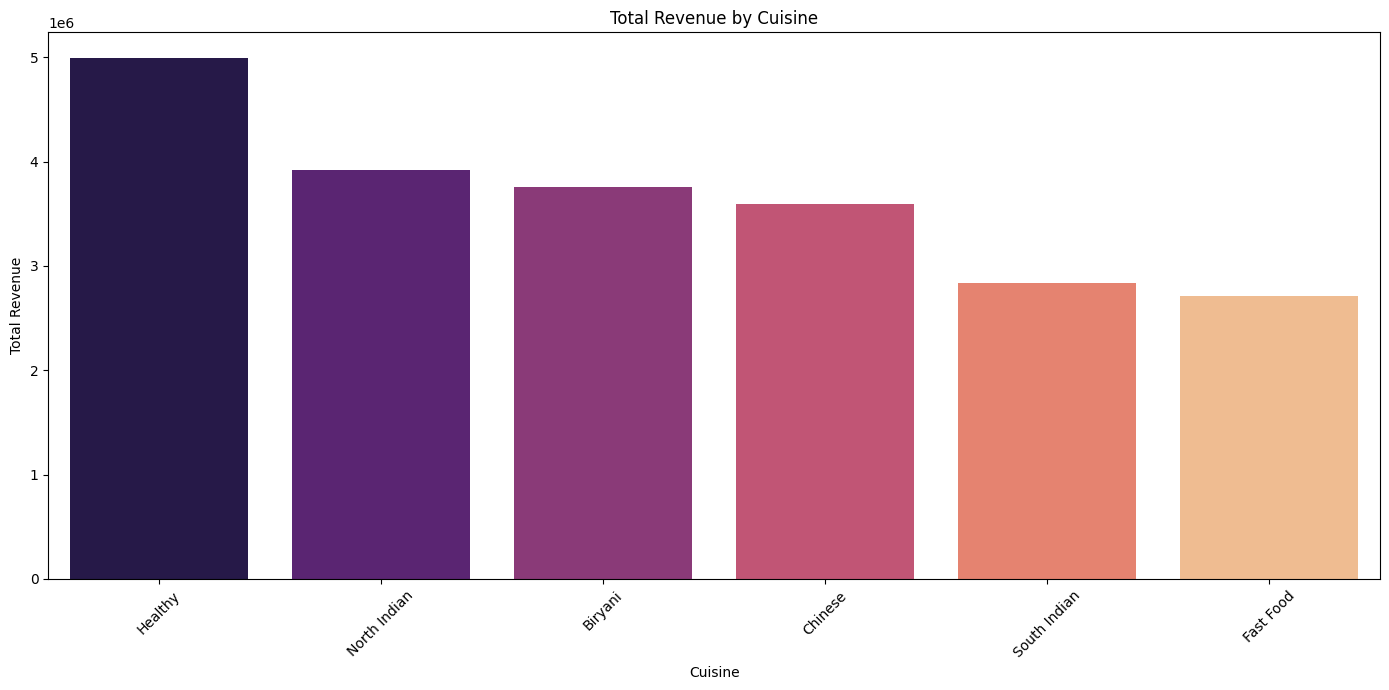

Interpretation: These bar charts provide insights into which cities and cuisines are generating the most orders and revenue, highlighting potential areas for focused marketing or expansion.


In [6]:
# Aggregate data by City
city_performance = df.groupby('City').agg({
    'Orders': 'sum',
    'Revenue': 'sum'
}).reset_index().sort_values(by='Revenue', ascending=False)

# Plotting Orders by City
plt.figure(figsize=(14, 7))
sns.barplot(x='City', y='Orders', data=city_performance, palette='viridis')
plt.title('Total Orders by City')
plt.xlabel('City')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plotting Revenue by City
plt.figure(figsize=(14, 7))
sns.barplot(x='City', y='Revenue', data=city_performance, palette='magma')
plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Aggregate data by Cuisine
cuisine_performance = df.groupby('Cuisine').agg({
    'Orders': 'sum',
    'Revenue': 'sum'
}).reset_index().sort_values(by='Revenue', ascending=False)

# Plotting Orders by Cuisine
plt.figure(figsize=(14, 7))
sns.barplot(x='Cuisine', y='Orders', data=cuisine_performance, palette='viridis')
plt.title('Total Orders by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plotting Revenue by Cuisine
plt.figure(figsize=(14, 7))
sns.barplot(x='Cuisine', y='Revenue', data=cuisine_performance, palette='magma')
plt.title('Total Revenue by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Interpretation: These bar charts provide insights into which cities and cuisines are generating the most orders and revenue, highlighting potential areas for focused marketing or expansion.")

## Relationship between Marketing Spend and Revenue

To understand the effectiveness of marketing efforts, we will visualize the relationship between 'Marketing_Spend' and 'Revenue' using a scatter plot. A positive correlation would suggest that increased marketing spend leads to higher revenue.

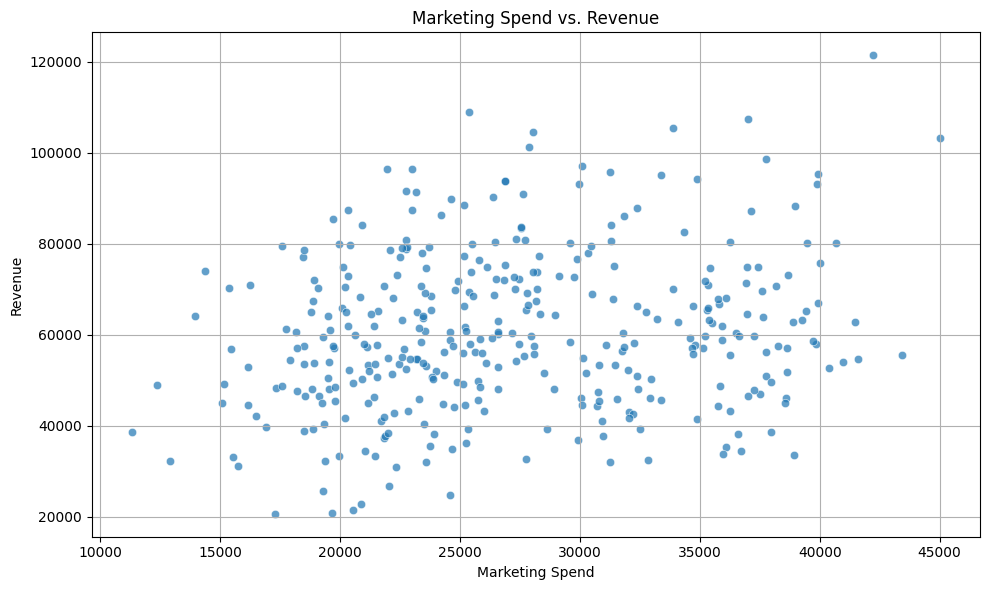

Correlation between Marketing Spend and Revenue: 0.20
Interpretation: This scatter plot and the correlation coefficient help us understand if there's a linear relationship between marketing investment and the revenue generated. A higher positive correlation indicates that as marketing spend increases, revenue tends to increase as well.


In [7]:
# Scatter plot for Marketing Spend vs. Revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Marketing_Spend', y='Revenue', alpha=0.7)
plt.title('Marketing Spend vs. Revenue')
plt.xlabel('Marketing Spend')
plt.ylabel('Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate and print the correlation coefficient
correlation = df['Marketing_Spend'].corr(df['Revenue'])
print(f"Correlation between Marketing Spend and Revenue: {correlation:.2f}")

print("Interpretation: This scatter plot and the correlation coefficient help us understand if there's a linear relationship between marketing investment and the revenue generated. A higher positive correlation indicates that as marketing spend increases, revenue tends to increase as well.")